In [1]:
# first import all packages you might need
%matplotlib inline
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tabulate import tabulate
from scipy.io import loadmat
import AirSeaFluxCode.AirSeaFluxCode as asfc

---
# HW1 Code

## Data Input, Cleaning, and Reorganization

In [2]:
#Filename input, and initializing lists for dataclean outputs
filenames = [
    "Transfer_Pioneer_6_v3.mat",
    "Transfer_Pioneer_7_v3.mat",
    "Transfer_Pioneer_8_v3.mat"
]

dfs = []
all_metadata = {}

#data reorganization loop
for path in filenames:
    
    mat = loadmat(path)
    #filter matlab internal fields
    mat = {k: v for k, v in mat.items() if not k.startswith("__")}
    #squeeze arrays
    mat = {k: np.squeeze(v) for k, v in mat.items()}
    #get length of each dataframe to separate variables and metadata
    lengths = {k: np.size(v) for k, v in mat.items() if isinstance(v, np.ndarray)}
    target_len = max(set(lengths.values()), key=list(lengths.values()).count)

    #initialize dictionaries for both and loop through each key in the dictionary
    data = {}
    metadata = {}
    for k, v in mat.items():
        if isinstance(v, np.ndarray) and np.size(v) == target_len:
            data[k] = np.ravel(v)
        else:
            metadata[k] = v

    #turn variables into dataframe
    df = pd.DataFrame(data)
    #convert from MATLAB time to datetime
    if "mtime" in df:
        df["time"] = pd.to_datetime(df["mtime"] - 719529, unit="D")
    df["source_file"] = path
    dfs.append(df)
    all_metadata[path] = metadata

# combine all files
df = pd.concat(dfs, ignore_index=True)

df.attrs["metadata"] = all_metadata

In [3]:
nonzero = (df['Sbytes'] != 0).sum()
print(f"Percentage of the data that is not high quality: {100 * (nonzero / df.shape[0]):.2f}%")

Percentage of the data that is not high quality: 15.82%


---
## Task 1

In [4]:
from windrose import WindroseAxes
import matplotlib.cm as cm

Text(0.5, 1.0, 'Wind Rose')

<Figure size 700x700 with 0 Axes>

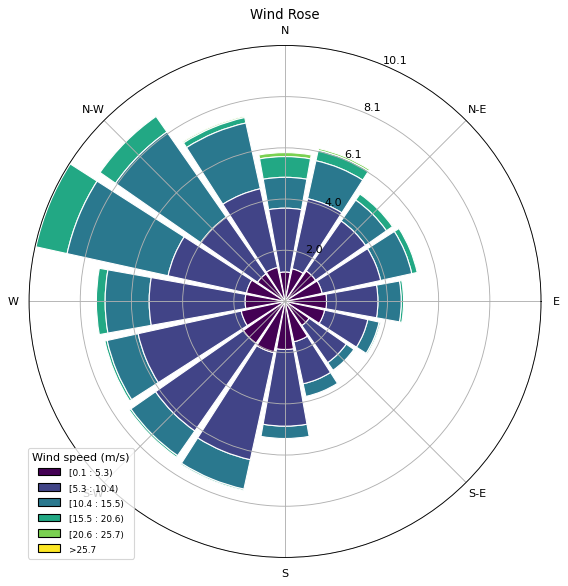

In [221]:
wd = df['Wdir']   # wind direction, degrees
ws = df['U10e']   # wind speed, m/s
#Filter NaN values
mask = np.isfinite(wd) & np.isfinite(ws)
wd = wd[mask]
ws = ws[mask]

#Plot
fig = plt.figure(figsize=(7,7))
ax = WindroseAxes.from_ax()

ax.bar(
    wd,
    ws,
    normed=True,
    opening=0.9,
    edgecolor='white',
    cmap=cm.viridis  
)

ax.set_legend(title="Wind speed (m/s)")
plt.title("Wind Rose")
#plt.savefig("./PS1_figures/Wind_Rose.png")
#plt.show()

Text(0.5, 1.0, 'Current Rose')

<Figure size 700x700 with 0 Axes>

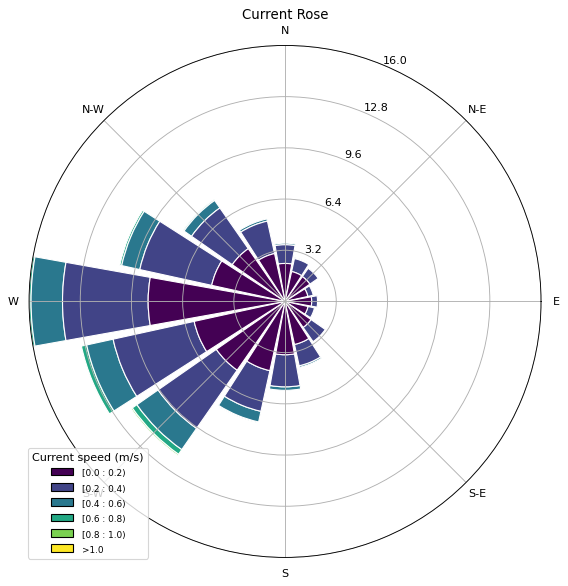

In [222]:
cn = df['CN']   # N current vel, m/s
ce = df['CE']   # E current vel, m/s

#convert to polar
speed = np.sqrt(cn**2 + ce**2)
direction = (np.degrees(np.arctan2(ce, cn)) + 360) % 360  # Degrees relative to N

# Filter out NaNs
mask = np.isfinite(speed) & np.isfinite(direction)
speed = speed[mask]
direction = direction[mask]

#plot
fig = plt.figure(figsize=(7,7))
ax = WindroseAxes.from_ax()

ax.bar(
    direction,
    speed,
    normed=True,
    opening=0.9,
    edgecolor='white',
    cmap=cm.viridis
)

ax.set_legend(title="Current speed (m/s)")
plt.title("Current Rose")
#plt.savefig("./PS1_figures/Current_Rose.png")
#plt.show()

<Figure size 700x700 with 0 Axes>

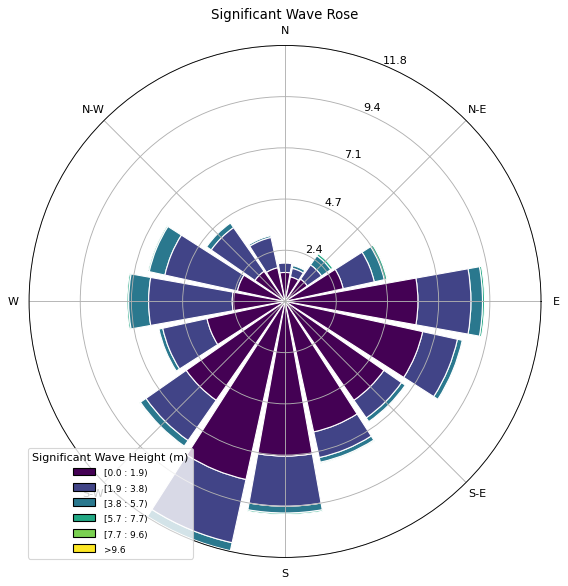

9.579999923706055

In [8]:
wd = df['sigHDir']   #significant wave direction, degrees
ws = df['sigH']   #significant wave height, m
#Filter NaN values
mask = np.isfinite(wd) & np.isfinite(ws)
wd = wd[mask]
ws = ws[mask]

#Plot
fig = plt.figure(figsize=(7,7))
ax = WindroseAxes.from_ax()

ax.bar(
    wd,
    ws,
    normed=True,
    opening=0.9,
    edgecolor='white',
    #bins=np.arange(0, 16, 2), 
    cmap=cm.viridis  
)

ax.set_legend(title="Significant Wave Height (m)")
plt.title("Significant Wave Rose")
#plt.savefig("./PS1_figures/Wave_Rose.png")
plt.show()
ws.max()

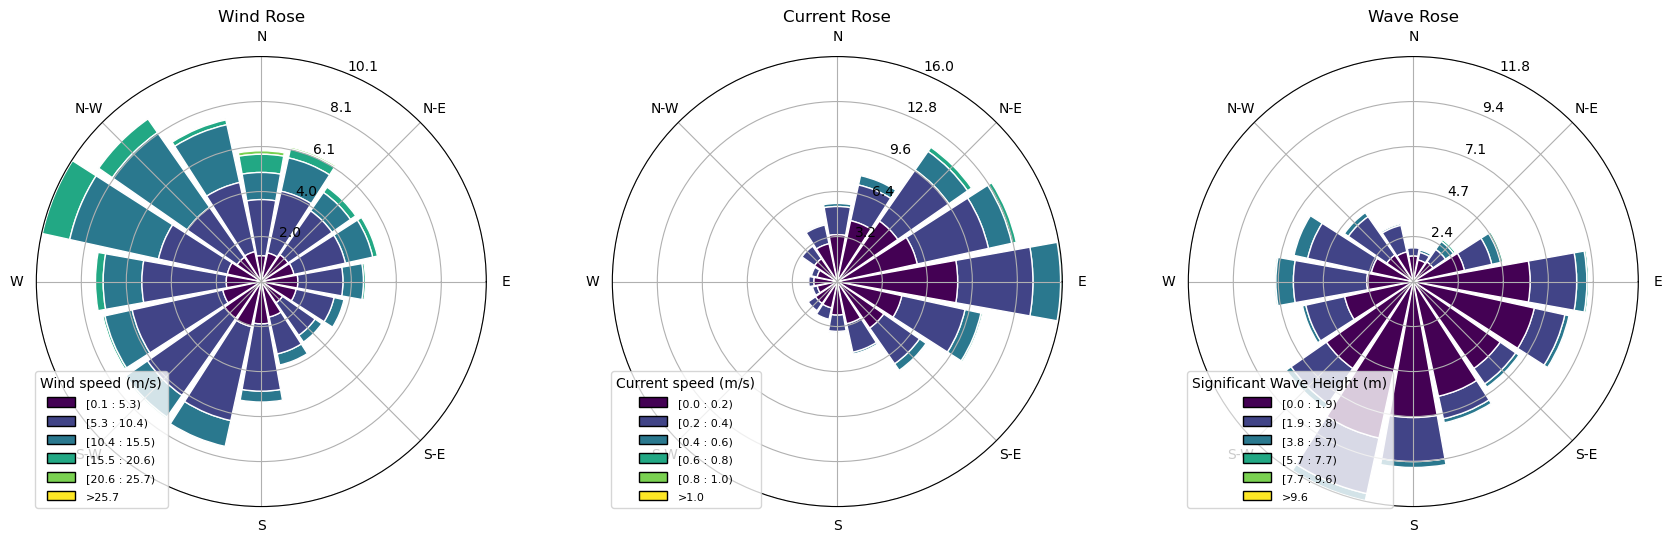

In [9]:
# Wind
wd_wind = df['Wdir']
ws_wind = df['U10e']
mask_wind = np.isfinite(wd_wind) & np.isfinite(ws_wind)
wd_wind = wd_wind[mask_wind]
ws_wind = ws_wind[mask_wind]

# Current
cn = df['CN']
ce = df['CE']
mask_current = np.isfinite(cn) & np.isfinite(ce)
cn = cn[mask_current]
ce = ce[mask_current]
speed_current = np.sqrt(cn**2 + ce**2)
direction_current = (np.degrees(np.arctan2(ce, cn)) + 360) % 360
direction_current = (direction_current + 180) % 360

# Waves
wd_wave = df['sigHDir']
ws_wave = df['sigH']
mask_wave = np.isfinite(wd_wave) & np.isfinite(ws_wave)
wd_wave = wd_wave[mask_wave]
ws_wave = ws_wave[mask_wave]

fig = plt.figure(figsize=(18,12))  

# Wind Rose
ax1 = WindroseAxes.from_ax(fig=fig, rect=[0.05, 0.1, 0.25, 0.8])
ax1.bar(
    wd_wind, ws_wind, normed=True, opening=0.9,
    edgecolor='white', cmap=cm.viridis
)
ax1.set_legend(title="Wind speed (m/s)")
ax1.set_title("Wind Rose")

# Current Rose
ax2 = WindroseAxes.from_ax(fig=fig, rect=[0.37, 0.1, 0.25, 0.8])
ax2.bar(
    direction_current, speed_current, normed=True, opening=0.9,
    edgecolor='white', cmap=cm.viridis
)
ax2.set_legend(title="Current speed (m/s)")
ax2.set_title("Current Rose")

# Wave Rose
ax3 = WindroseAxes.from_ax(fig=fig, rect=[0.69, 0.1, 0.25, 0.8])
ax3.bar(
    wd_wave, ws_wave, normed=True, opening=0.9,
    edgecolor='white', cmap=cm.viridis
)
ax3.set_legend(title="Significant Wave Height (m)")
ax3.set_title("Wave Rose")
#plt.savefig('./PS1_figures/Rose_multiplot.png')
plt.show()

Number of outliers filtered out: 605


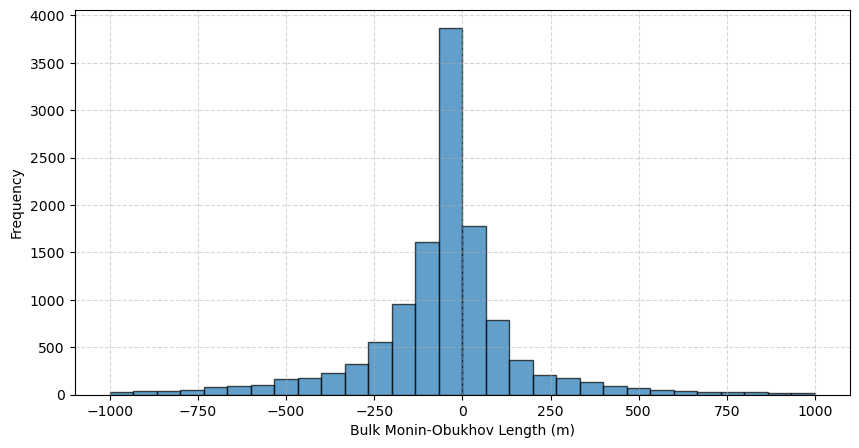

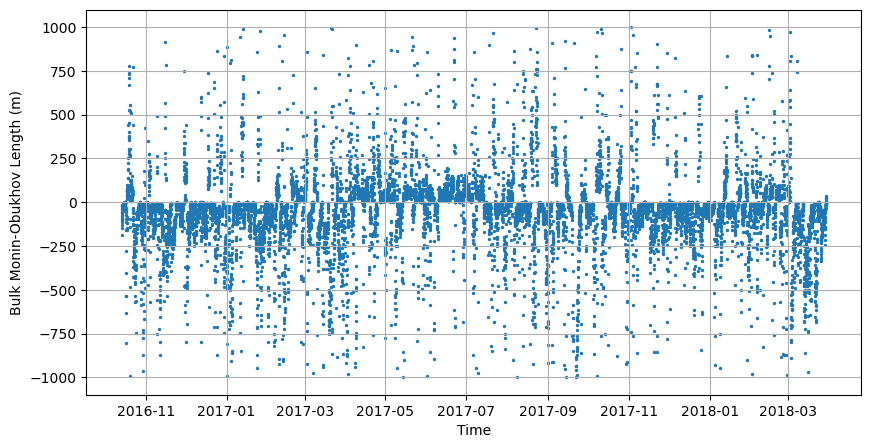

In [10]:
time = df['time'] #times
L = df['moL'] #Bulk Monin-Obukhov length (m)

# Filter out NaNs
mask = np.isfinite(L)
time = time[mask]
L = L[mask]

#filter out unphysical outliers
valid_mask = (L >= -1000) & (L <= 1000)
n_outliers = np.sum(~valid_mask)
print(f"Number of outliers filtered out: {n_outliers}")

# Apply mask
time = time[valid_mask]
L = L[valid_mask]

plt.figure(figsize=(10,5))
plt.hist(L, bins=30, edgecolor='black', alpha=0.7)  # adjust bins as needed
plt.xlabel("Bulk Monin-Obukhov Length (m)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
#plt.savefig('./PS1_figures/Monin_Obukhov_histogram.png')
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(time, L, s=2)
plt.xlabel("Time")
plt.ylabel("Bulk Monin-Obukhov Length (m)")
plt.grid(True)
#plt.savefig('./PS1_figures/Monin_Obukhov.png')
plt.show()



In [11]:
print(f'Percentage of data points falling outside set bounds {n_outliers/ len(L) * 100:.2f}%')

Percentage of data points falling outside set bounds 4.99%


In [12]:
L = df['moL']

#filter NaNs
mask = np.isfinite(L)
L_valid = L[mask]

#count positive and negative
n_positive = np.sum(L_valid > 50)
n_negative = np.sum(L_valid < -50)
total = len(L_valid)
n_neutral = len(L_valid) - n_positive - n_negative

print(f"Percentage of stable values: {100 *n_positive/total:.2f}%")
print(f"Percentage of near-neutral values: {100 * n_neutral/total:.2f}%")
print(f"Percentage of unstable values: {100 * n_negative/total:.2f}%")

Percentage of stable values: 20.62%
Percentage of near-neutral values: 36.71%
Percentage of unstable values: 42.67%


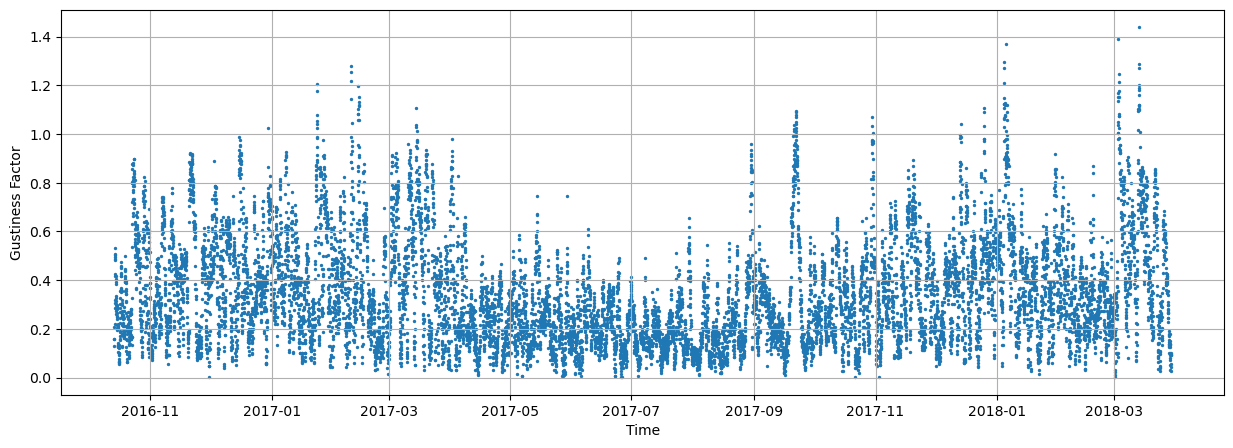

In [13]:
time = df['time'] #datetime
gust = df['usr'] #gustiness, no unit
mask = np.isfinite(gust)
time = time[mask]
gust = gust[mask]

plt.figure(figsize=(15,5))
plt.scatter(time,gust, s=2)
plt.xlabel("Time")
plt.ylabel("Gustiness Factor")
plt.grid(True)
plt.savefig('./PS1_figures/Gustiness.png')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

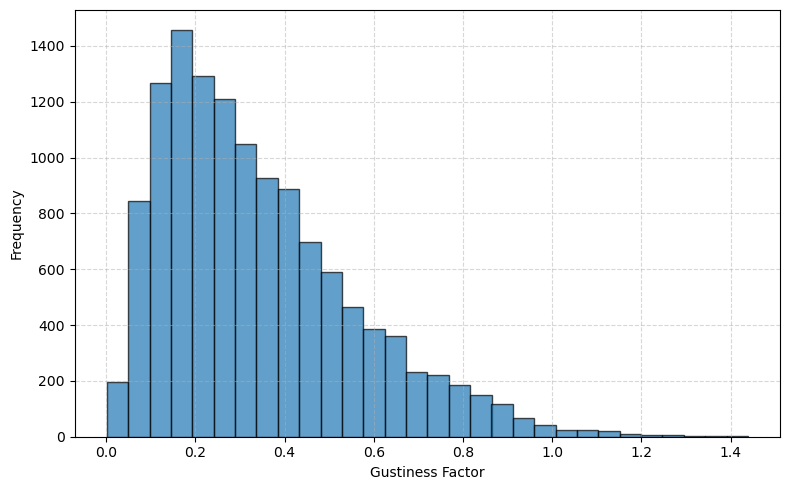

In [14]:
# Create histogram
plt.figure(figsize=(8,5))
plt.hist(gust, bins=30, edgecolor='black', alpha=0.7)  # adjust bins as needed
plt.xlabel("Gustiness Factor")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('./PS1_figures/Gustiness_histogram.png')
plt.show

In [15]:
#filter NaNs
mask = np.isfinite(gust)
gust_valid = gust[mask]

# define bins
n_low = np.sum(gust_valid < 0.2)
n_moderate = np.sum((gust_valid >= 0.2) & (gust_valid < 0.4))
n_high = np.sum((gust_valid >= 0.4) & (gust_valid < 0.6))
n_very_high = np.sum(gust_valid >= 0.6)
total = len(gust_valid)

print(f"Percentage of low gustiness (0-0.2): {100 * n_low / total:.2f}%")
print(f"Percentage of moderate gustiness (0.2-0.4): {100 * n_moderate / total:.2f}%")
print(f"Percentage of high gustiness (0.4-0.6): {100 * n_high / total:.2f}%")
print(f"Percentage of very high gustiness (0.6+): {100 * n_very_high / total:.2f}%")

Percentage of low gustiness (0-0.2): 31.13%
Percentage of moderate gustiness (0.2-0.4): 35.95%
Percentage of high gustiness (0.4-0.6): 19.89%
Percentage of very high gustiness (0.6+): 13.03%


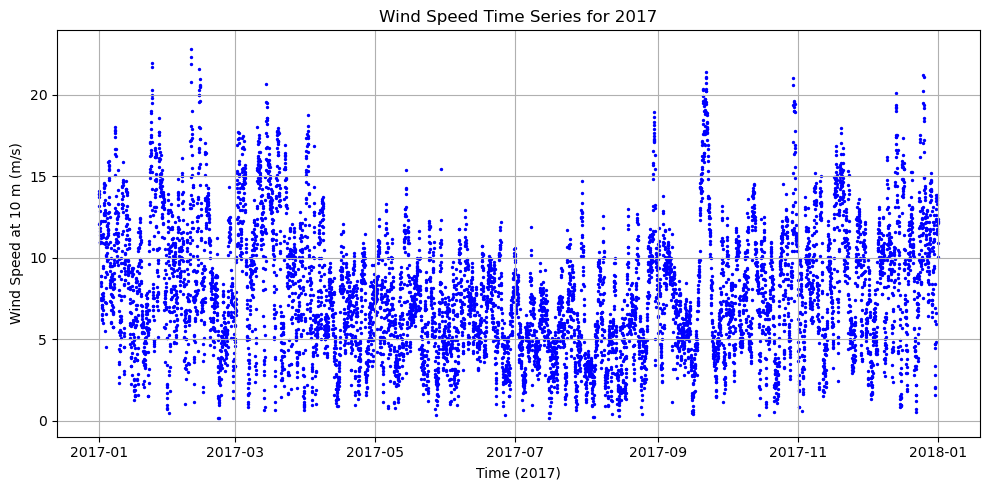

In [16]:
time = df['time']  # datetim
ws = df['U10e']   # wind speed relative to earth @ 10m (m/s)

mask = np.isfinite(ws)
time = time[mask]
ws = ws[mask]

# filter for 2017
year_mask = time.dt.year == 2017
time_2017 = time[year_mask]
ws_2017 = ws[year_mask]

# plot
plt.figure(figsize=(10,5))
plt.scatter(time_2017, ws_2017, s=2, color='blue')
plt.xlabel("Time (2017)")
plt.ylabel("Wind Speed at 10 m (m/s)")
plt.title("Wind Speed Time Series for 2017")
plt.grid(True)
plt.tight_layout()
#plt.savefig('./PS1_figures/WindSpeed_2017.png')
plt.show()

---
# Task #2

### AirSeaFluxCode Quick Reference

The below Code is an example from the AirSeaFluxCode github using some given example data from a research vessel. At a minimum, the code requires:
 - Wind speed
 - Air temperature
 - Sea surface Temperature
 - The type of the input SST; “bulk” or “skin”

Outputs 

 - Wind stress (tau)
 - Sensible heat flux (sensible)
 - Latent heat flux (latent)
 - Wind speed (u10n)
 - The list goes on, documentation for full outputs is in Documentation.pdf

The default settings for the code include:
 - Outputs are corrected to be their values at 10 meters
 - Cool skin/warm layer corrections are not desired
 - The desired algorithm is the one from Smith 1988
 - Gustiness effects are taken into account
 - Saturation vapor pressure is found using Buck 2012
 - Standard tolerence limits for both flux estimates and height adjusted variables (['all', 0.01, 0.01, 1e-05, 1e-3, 0.1, 0.1])
 - 10 iterations are desired
 - Non converged points are considered missing
 - Monin-Obukhov stability length is calculated following the ECMWF implementation



### ASFC Flags

| Flag Value | Flag Description | Default Action |
|------------|------------------|----------------|
| m | input data missing | output missing |
| u | negative (non-physical) u10n or u10n > 200 m s⁻¹ | output missing |
| q | negative (non-physical) q10n or q10n > 4 × 10⁻² kg/kg | output missing |
| t | T10n < 173 K or T10n > 373 K | output missing |
| i | failure to converge after the maximum number of iterations | output missing |
| l | either the bulk Richardson number is out of the typical range −0.5 < Rb < 0.2, or where \|zm/L\| > 1000 (which would imply extreme stability values) | retain value |
| o | out of nominal wind speed range (see column “valid range” in main text Table 1) | retain value |
| r | relative humidity greater than 100% | retain value |
| n | no other flag set | retain value |

---
# Task 3

Compare the parameterized wind stress, Cd, and/or z0 using AirSeaFluxCode based on the OOI bulk meteorological variables as input data.

 - A. Make quantitative or statistical comparisons of the bulk estimates of wind stress against directly measured stress.
 - B. Does using absolute wind vs relative wind make any difference for stress estimates? If so, when? If not, why?
 - C. Discuss (with evidence) when the estimated momentum flux agrees or disagrees the most (e.g., stable vs. unstable regimes, strong vs. weak wind regimes).
 - D. Under what conditions do you see the departure of the estimated wind stress from the directly measured? Which schemes (if any) do a better job consistently?

In [17]:
date = np.asarray(df["time"])
df["lat"] = df["source_file"].map(lambda x: all_metadata.get(x, {}).get("lat"))
lat = np.asarray(df["lat"])
spd = np.asarray(df["U10r"]) # relative wind speed in [m/s] (is assumed as magnitude difference between wind and surface currentvectors)
t = np.asarray(df["T10"])  # Air Temperature(will convert if< 200and ‘convert’ is True)
sst = np.asarray(df["SST"]) # seasurface temperature [K](will convert if <200 and‘convert’isTrue)
rh = np.asarray(df["RH10"]) #currently for 10 meters, double check this
p = np.asarray(df["P10"]) # Pressure at 10m in mb or hPa
hin = 10 #height of input variables (m)
outvar = ("tau", "cd", "zo")

# run AirSeaFluxCode
temp_res = asfc.AirSeaFluxCode(
    spd,
    t,
    sst,
    "skin",
    meth='ecmwf',
    lat=lat,
    hin=10,
    hout=10,
    hum=["rh", rh],
    P=p,
    convert=True,
    out_var=outvar,
)


temp_res['time'] = df['time']
flg = temp_res["flag"]

In [18]:
unique_flags = flg.unique()
for i in range(len(unique_flags)):
    count = (flg == unique_flags[i]).sum()
    print(f"number of {unique_flags[i]} flags: {count}")

number of m flags: 22
number of n flags: 12498
number of l flags: 118
number of q,l flags: 42
number of q flags: 3
number of r flags: 77


In [19]:
res = temp_res[temp_res['flag'] == 'n']
print(f'{temp_res.shape[0] - res.shape[0]} bad entries removed from the original {temp_res.shape[0]} entries')

262 bad entries removed from the original 12760 entries


In [20]:
tau_meas = df[['time', 'stress']]
tau_bulk = res[['time','tau']]
tau = pd.merge(tau_meas, tau_bulk, on="time", how="inner")
tau = tau.rename(columns={"stress": "measured", "tau":"bulk"})

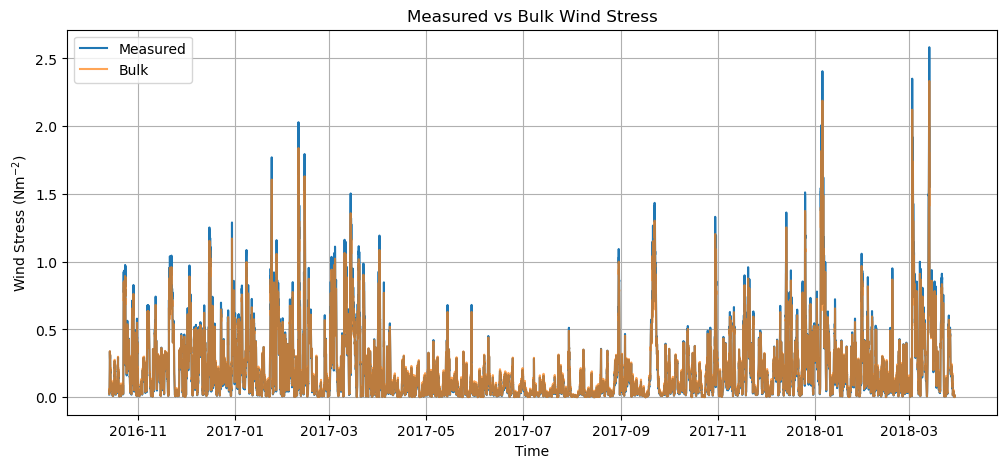

In [21]:
plt.figure(figsize=(12,5))
plt.plot(tau['time'], tau['measured'], label='Measured')
plt.plot(tau['time'], tau['bulk'], label='Bulk', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Wind Stress (Nm$^{-2}$)')
plt.title('Measured vs Bulk Wind Stress')
plt.legend()
plt.grid(True)
#plt.savefig('./PS1_figures/tau_series.png')
plt.show()

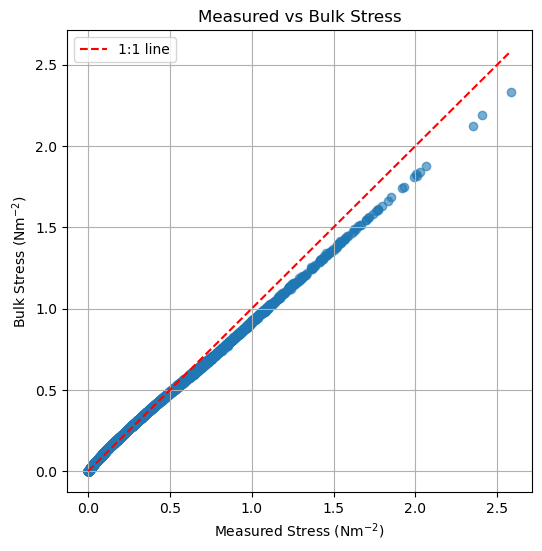

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(tau['measured'], tau['bulk'], alpha=0.6)
plt.plot([tau['measured'].min(), tau['measured'].max()],
         [tau['measured'].min(), tau['measured'].max()],
         'r--', label='1:1 line')
plt.xlabel('Measured Stress (Nm$^{-2}$)')
plt.ylabel('Bulk Stress (Nm$^{-2}$)')
plt.title('Measured vs Bulk Stress')
plt.legend()
plt.grid(True)
plt.savefig('./PS1_figures/stress_scatter.png')
plt.show()

In [23]:
from scipy.stats import linregress

#Differences
tau['diff'] = tau['measured'] - tau['bulk']

# Statistics
mean_diff = tau['diff'].mean()
std_diff  = tau['diff'].std()
rmse = np.sqrt(np.mean(tau['diff']**2))

# Linear regression (bulk vs measured)
slope, intercept, r_value, p_value, std_err = linregress(tau['measured'], tau['bulk'])

print(f"Mean difference: {mean_diff:.3f} N m⁻²")
print(f"Standard deviation of difference: {std_diff:.3f} N m⁻²")
print(f"RMSE: {rmse:.3f} N m⁻²")
print(f"Linear fit: bulk = {slope:.3f} * measured + {intercept:.3f}")
print(f"R² = {r_value**2:.3f}")

Mean difference: -0.001 N m⁻²
Standard deviation of difference: 0.024 N m⁻²
RMSE: 0.024 N m⁻²
Linear fit: bulk = 0.916 * measured + 0.019
R² = 0.998


In [24]:
spd2 = np.asarray(df["U10e"]) # absolute wind speed in [m/s] (is assumed as magnitude difference between wind and surface currentvectors)

# run AirSeaFluxCode
temp_res2 = asfc.AirSeaFluxCode(
    spd2,
    t,
    sst,
    "skin",
    meth='ecmwf',
    lat=lat,
    hin=10,
    hout=10,
    hum=["rh", rh],
    P=p,
    convert=True,
    out_var=outvar,
)

temp_res2['time'] = df['time']
flg2 = temp_res2["flag"]

In [25]:
res2 = temp_res2[temp_res2['flag'] == 'n']
print(f'{temp_res2.shape[0] - res2.shape[0]} bad entries removed from the original {temp_res2.shape[0]} entries')

tau_meas = df[['time', 'stress']]
tau_bulk2 = res2[['time','tau']]
tau2 = pd.merge(tau_meas, tau_bulk2, on="time", how="inner")
tau2 = tau2.rename(columns={"stress": "measured", "tau":"bulk"})

285 bad entries removed from the original 12760 entries


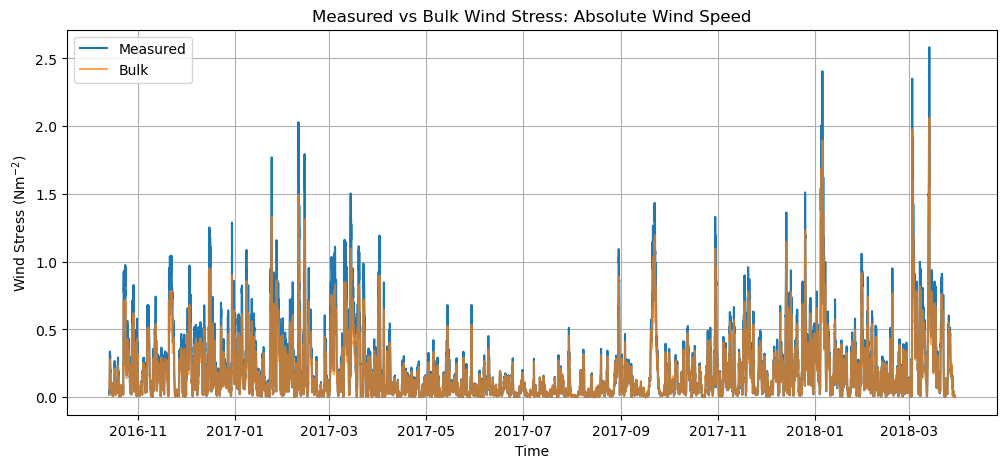

In [223]:
plt.figure(figsize=(12,5))
plt.plot(tau2['time'], tau2['measured'], label='Measured')
plt.plot(tau2['time'], tau2['bulk'], label='Bulk', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Wind Stress (Nm$^{-2}$)')
plt.title('Measured vs Bulk Wind Stress: Absolute Wind Speed')
plt.legend()
plt.grid(True)
#plt.savefig('./PS1_figures/abs_tau_time.png')
plt.show()

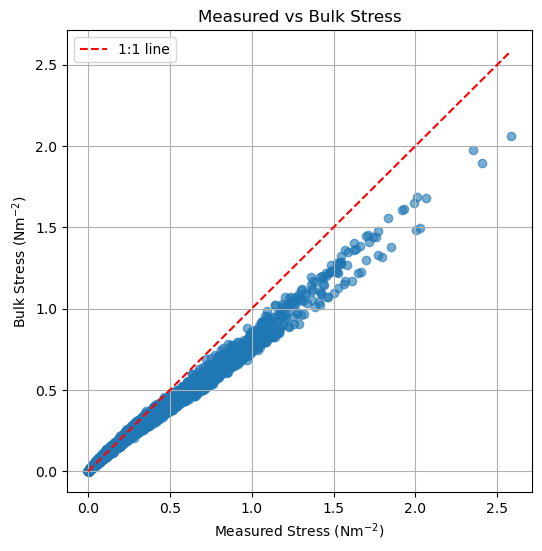

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(tau2['measured'], tau2['bulk'], alpha=0.6)
plt.plot([tau2['measured'].min(), tau2['measured'].max()],
         [tau2['measured'].min(), tau2['measured'].max()],
         'r--', label='1:1 line')
plt.xlabel('Measured Stress (Nm$^{-2}$)')
plt.ylabel('Bulk Stress (Nm$^{-2}$)')
plt.title('Measured vs Bulk Stress')
plt.legend()
plt.grid(True)
#plt.savefig('./PS1_figures/abs_tau_scatter.png')
plt.show()

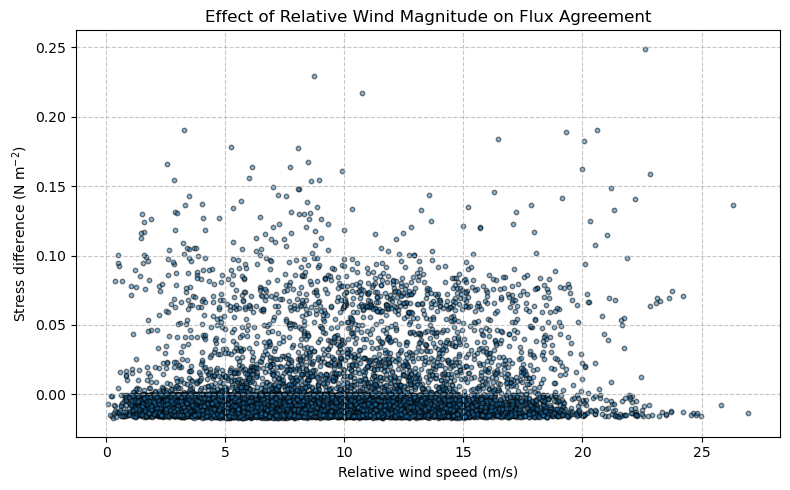

In [33]:
windspeed = df['U10r']
stress_diff = tau['diff']

mask = np.isfinite(windspeed) & np.isfinite(stress_diff)
windspeed_clean = windspeed[mask]
stress_diff_clean = stress_diff[mask]

plt.figure(figsize=(8,5))

plt.scatter(
    windspeed_clean,
    stress_diff_clean,
    alpha=0.5,
    edgecolor='k',
    s=10
)

plt.xlabel("Relative wind speed (m/s)")
plt.ylabel("Stress difference (N m$^{-2}$)")
plt.title("Effect of Relative Wind Magnitude on Flux Agreement")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.savefig('./PS1_figures/wind_variation.png')
plt.show()

In [34]:
slope, intercept, r_value, p_value, std_err = linregress(
    windspeed_clean, stress_diff_clean
)

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_value**2)
print("p-value:", p_value)

Slope: 0.0006446687848634646
Intercept: -0.007111201699248008
R²: 0.013287945273827418
p-value: 3.5924369835072617e-38


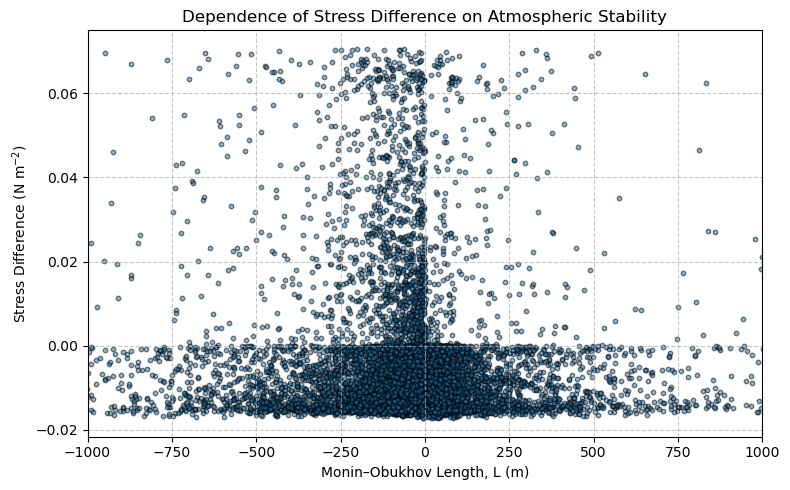

In [35]:
from scipy.stats import zscore

L = df['moL']
stress_diff = tau['diff']

mask = np.isfinite(L) & np.isfinite(stress_diff)
L_clean = L[mask]
stress_diff_clean = stress_diff[mask]

mask = (
    (np.abs(zscore(L_clean)) < 3) &
    (np.abs(zscore(stress_diff_clean)) < 3)
)

L_filtered = L_clean[mask]
stress_filtered = stress_diff_clean[mask]

plt.figure(figsize=(8,5))

plt.scatter(
    L_filtered,
    stress_filtered,
    alpha=0.5,
    edgecolor='k',
    s=10
)

plt.xlabel("Monin–Obukhov Length, L (m)")
plt.ylabel("Stress Difference (N m$^{-2}$)")
plt.xlim(-1000, 1000)
plt.title("Dependence of Stress Difference on Atmospheric Stability")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.savefig('./PS1_figures/moL_stress_effect.png')
plt.show()

In [36]:
slope, intercept, r_value, p_value, std_err = linregress(
    L_filtered, stress_filtered
)

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_value**2)
print("p-value:", p_value)

Slope: -9.412220060304296e-08
Intercept: -0.004660225125189693
R²: 4.978536779404226e-05
p-value: 0.43848180530512415


### LP82 Run

number of m flags: 22
number of n flags: 11644
number of l,o flags: 163
number of q,l flags: 47
number of l flags: 7
number of o flags: 653
number of i flags: 124
number of q flags: 7
number of i,o flags: 16
number of r,o flags: 17
number of r flags: 60
1116 bad entries removed from the original 12760 entries


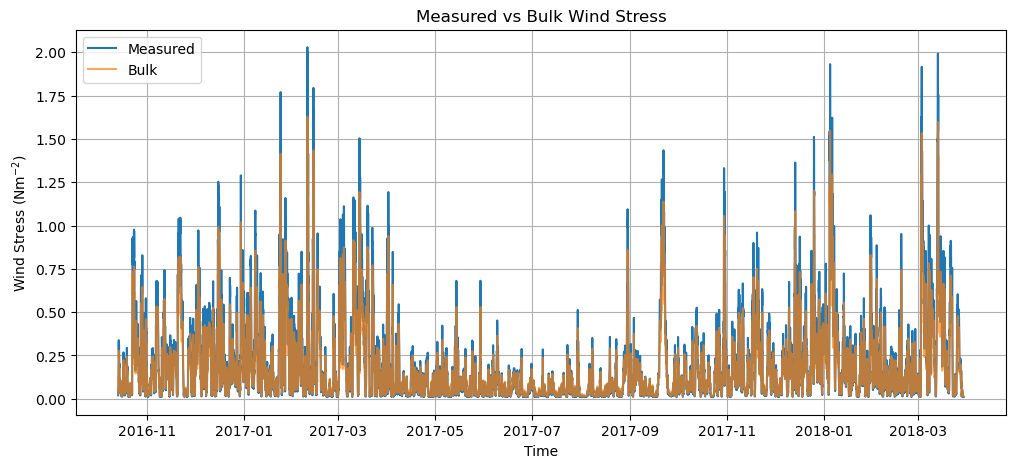

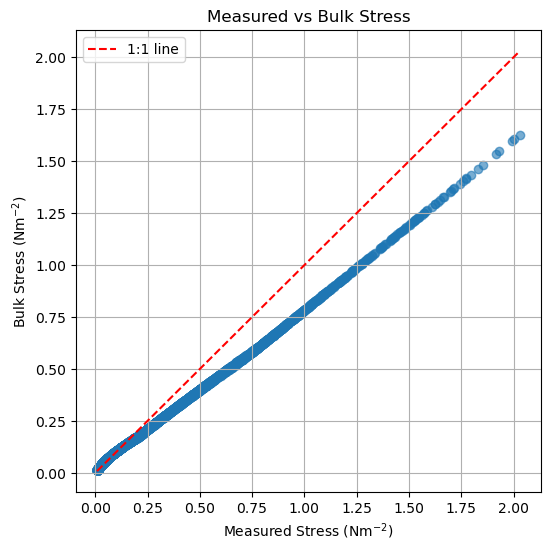

Mean difference: 0.031 N m⁻²
Standard deviation of difference: 0.060 N m⁻²
RMSE: 0.068 N m⁻²
Linear fit: bulk = 0.765 * measured + 0.020
R² = 0.999


In [226]:
date = np.asarray(df["time"])
df["lat"] = df["source_file"].map(lambda x: all_metadata.get(x, {}).get("lat"))
lat = np.asarray(df["lat"])
spd = np.asarray(df["U10r"]) # relative wind speed in [m/s] (is assumed as magnitude difference between wind and surface currentvectors)
t = np.asarray(df["T10"])  # Air Temperature(will convert if< 200and ‘convert’ is True)
sst = np.asarray(df["Tsea"]) # seasurface temperature [K](will convert if <200 and‘convert’isTrue)
rh = np.asarray(df["RH10"]) #currently for 10 meters, double check this
p = np.asarray(df["P10"]) # Pressure at 10m in mb or hPa
hin = 10 #height of input variables (m)
outvar = ("tau", "cd", "zo")

# run AirSeaFluxCode
temp_res = asfc.AirSeaFluxCode(
    spd,
    t,
    sst,
    "bulk",
    meth='LP82',
    lat=lat,
    hin=10,
    hout=10,
    hum=["rh", rh],
    P=p,
    convert=True,
    out_var=outvar,
)


temp_res['time'] = df['time']
flg = temp_res["flag"]



unique_flags = flg.unique()
for i in range(len(unique_flags)):
    count = (flg == unique_flags[i]).sum()
    print(f"number of {unique_flags[i]} flags: {count}")

res = temp_res[temp_res['flag'] == 'n']
print(f'{temp_res.shape[0] - res.shape[0]} bad entries removed from the original {temp_res.shape[0]} entries')

tau_meas = df[['time', 'stress']]
tau_bulk = res[['time','tau']]
tau = pd.merge(tau_meas, tau_bulk, on="time", how="inner")
tau = tau.rename(columns={"stress": "measured", "tau":"bulk"})

plt.figure(figsize=(12,5))
plt.plot(tau['time'], tau['measured'], label='Measured')
plt.plot(tau['time'], tau['bulk'], label='Bulk', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Wind Stress (Nm$^{-2}$)')
plt.title('Measured vs Bulk Wind Stress')
plt.legend()
plt.grid(True)
#plt.savefig('./PS1_figures/tau_series.png')
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(tau['measured'], tau['bulk'], alpha=0.6)
plt.plot([tau['measured'].min(), tau['measured'].max()],
         [tau['measured'].min(), tau['measured'].max()],
         'r--', label='1:1 line')
plt.xlabel('Measured Stress (Nm$^{-2}$)')
plt.ylabel('Bulk Stress (Nm$^{-2}$)')
plt.title('Measured vs Bulk Stress')
plt.legend()
plt.grid(True)
plt.show()

from scipy.stats import linregress

#Differences
tau['diff'] = tau['measured'] - tau['bulk']

# Statistics
mean_diff = tau['diff'].mean()
std_diff  = tau['diff'].std()
rmse = np.sqrt(np.mean(tau['diff']**2))

# Linear regression (bulk vs measured)
slope, intercept, r_value, p_value, std_err = linregress(tau['measured'], tau['bulk'])

print(f"Mean difference: {mean_diff:.3f} N m⁻²")
print(f"Standard deviation of difference: {std_diff:.3f} N m⁻²")
print(f"RMSE: {rmse:.3f} N m⁻²")
print(f"Linear fit: bulk = {slope:.3f} * measured + {intercept:.3f}")
print(f"R² = {r_value**2:.3f}")

---
# Task 4

Compare sensible and latent heat fluxes and the respective exchange coefficients using AirSeaFluxCode using the OOI bulk meteorological variables as input data. To make a comparison to OOI sonic buoyancy flux (WTr), please calculate the buoyancy flux

In [37]:
date = np.asarray(df["time"])
#lon = np.asarray(df["lon"])
lat = np.asarray(df["lat"])
spd = np.asarray(df["U10r"]) # relative wind speed in [m/s] (is assumed as magnitude difference between wind and surface currentvectors)
t = np.asarray(df["T10"])  # Air Temperature(will convert if< 200and ‘convert’ is True)
sst = np.asarray(df["SST"]) # seasurface temperature [K](will convert if <200 and‘convert’isTrue)
rh = np.asarray(df["RH10"]) #currently for 10 meters, double check this
p = np.asarray(df["P10"]) # Pressure at 10m in mb or hPa
hin = 10 #height of input variables (m)
outvar = ("sensible", "latent", "ct", "cq")

# run AirSeaFluxCode
temp_res = asfc.AirSeaFluxCode(
    spd,
    t,
    sst,
    "skin",
    meth='ecmwf',
    lat=lat,
    hin=10,
    hout=10,
    hum=["rh", rh],
    P=p,
    convert=True,
    out_var=outvar,
)


temp_res['time'] = df['time']
flg = temp_res["flag"]
unique_flags = flg.unique()
for i in range(len(unique_flags)):
    count = (flg == unique_flags[i]).sum()
    print(f"number of {unique_flags[i]} flags: {count}")

res = temp_res[temp_res['flag'] == 'n']
print(f'{temp_res.shape[0] - res.shape[0]} bad entries removed from the original {temp_res.shape[0]} entries')

heat = res[['time','sensible','latent','ct','cq']].copy()
heat = heat.rename(columns={
    'sensible':'sensible_flux',
    'latent':'latent_flux',
    'ct':'C_H',
    'cq':'C_Q'
})

number of m flags: 22
number of n flags: 12498
number of l flags: 118
number of q,l flags: 42
number of q flags: 3
number of r flags: 77
262 bad entries removed from the original 12760 entries


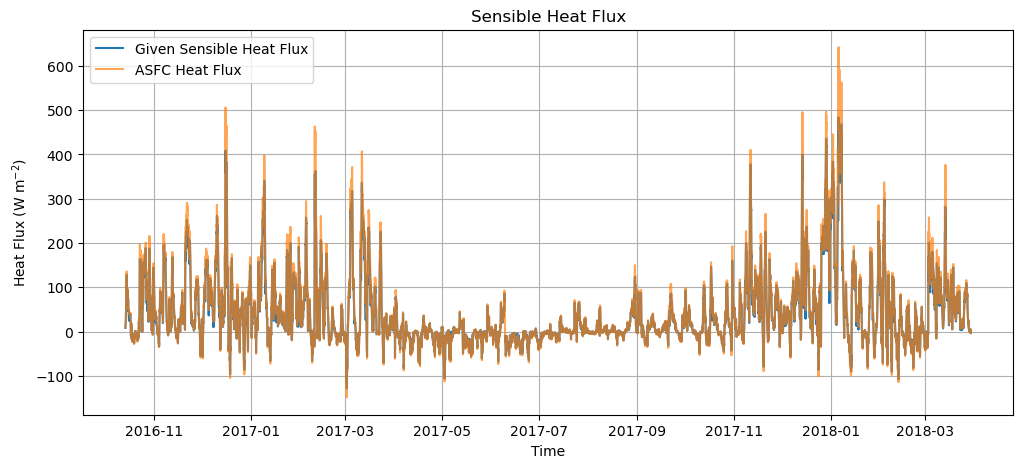

In [38]:
plt.figure(figsize=(12,5))

plt.plot(df['time'], df['shf'], label='Given Sensible Heat Flux')

plt.plot(heat['time'], -1 * heat['sensible_flux'], label='ASFC Heat Flux', color='tab:orange', alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Heat Flux (W m$^{-2}$)")
plt.title("Sensible Heat Flux")

plt.legend()
plt.grid(True)
plt.show()

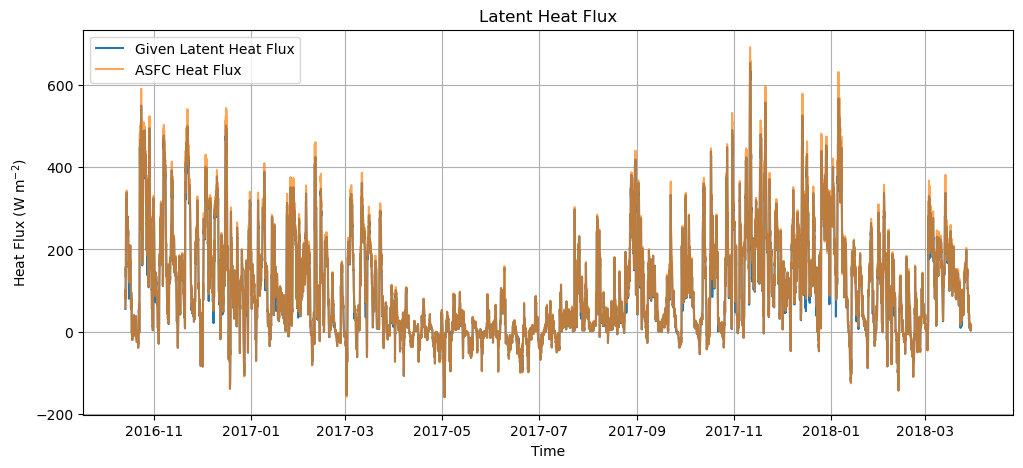

In [39]:
plt.figure(figsize=(12,5))

plt.plot(df['time'], df['lhf'], label='Given Latent Heat Flux')

plt.plot(heat['time'], -1 * heat['latent_flux'], label='ASFC Heat Flux', color='tab:orange', alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Heat Flux (W m$^{-2}$)")
plt.title("Latent Heat Flux")

plt.legend()
plt.grid(True)
plt.show()

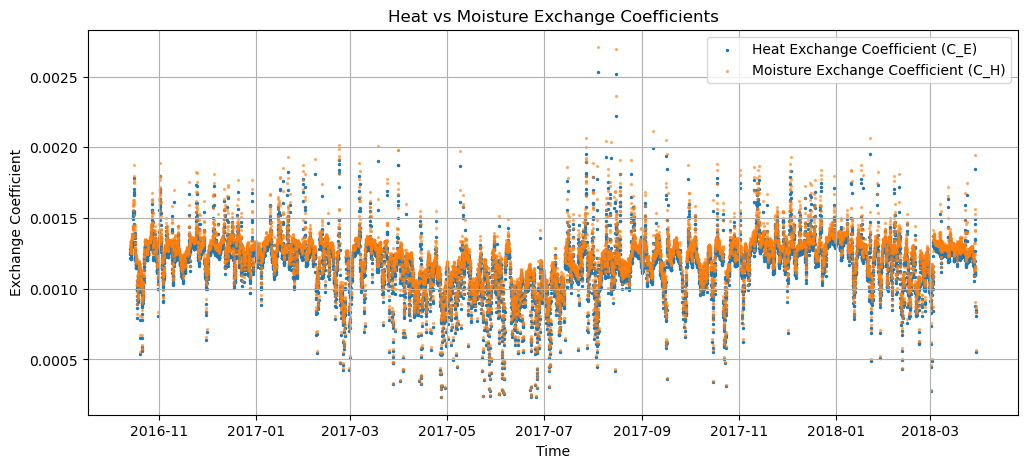

In [40]:
plt.figure(figsize=(12,5))


plt.scatter(heat['time'], heat['C_H'], label='Heat Exchange Coefficient (C_E)', s=2)
plt.scatter(heat['time'], heat['C_Q'], label='Moisture Exchange Coefficient (C_H)', s=2, alpha=.5)
#del plt.ylim 
#plt.ylim(0.001,0.002)
plt.xlabel("Time")
plt.ylabel("Exchange Coefficient")
plt.title("Heat vs Moisture Exchange Coefficients")

plt.legend()
plt.grid(True)
plt.show()

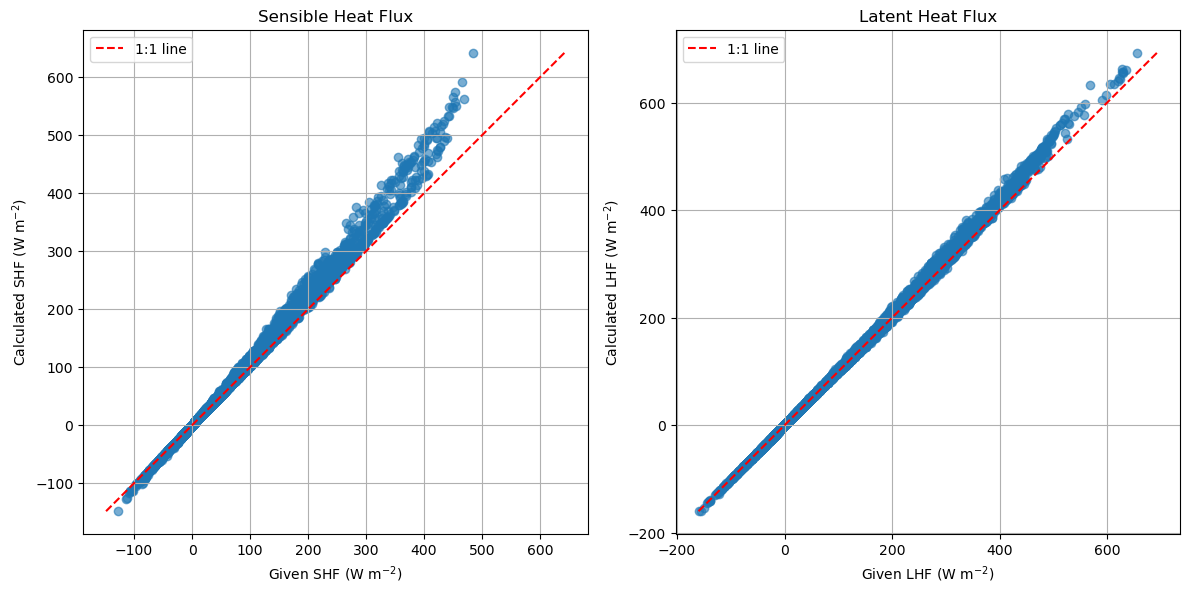

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

m = df[['time','shf']].merge(heat[['time','sensible_flux']], on='time')

x = m['shf']
y = -m['sensible_flux']

ax[0].scatter(x, y, alpha=0.6)

lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
ax[0].plot([lo, hi], [lo, hi], 'r--', label='1:1 line')

ax[0].set(
    xlabel='Given SHF (W m$^{-2}$)',
    ylabel='Calculated SHF (W m$^{-2}$)',
    title='Sensible Heat Flux'
)
ax[0].grid(True)
ax[0].legend()
ax[0].set_aspect('equal', adjustable='box')


m = df[['time','lhf']].merge(heat[['time','latent_flux']], on='time')

x = m['lhf']
y = -m['latent_flux']

ax[1].scatter(x, y, alpha=0.6)

lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
ax[1].plot([lo, hi], [lo, hi], 'r--', label='1:1 line')

ax[1].set(
    xlabel='Given LHF (W m$^{-2}$)',
    ylabel='Calculated LHF (W m$^{-2}$)',
    title='Latent Heat Flux'
)
ax[1].grid(True)
ax[1].legend()
ax[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import r2_score, mean_squared_error

In [45]:
fluxes = [
    ('shf', 'sensible_flux', 'Sensible Heat Flux'),
    ('lhf', 'latent_flux', 'Latent Heat Flux')
]

for df_col, heat_col, name in fluxes:
    m = df[['time', df_col]].merge(heat[['time', heat_col]], on='time')
    x = m[df_col]
    y = -m[heat_col]  
    
    r2 = r2_score(y, x)
    rmse = np.sqrt(mean_squared_error(y, x))

    print(f"{name}:")
    print(f"  R²: {r2:.3f}")
    print(f"  RMSE: {rmse:.3f} W/m²\n")

Sensible Heat Flux:
  R²: 0.983
  RMSE: 11.162 W/m²

Latent Heat Flux:
  R²: 0.997
  RMSE: 6.450 W/m²



$$
B = \frac{g}{\theta_v}\left(\frac{H}{\rho_{air} c_p} + 0.61\theta \frac{Q_L}{\rho_a L_v}\right)
$$

In [46]:
g = 9.81 #m/s²

cpa_mapping = {fname: meta['cpa'].item() for fname, meta in all_metadata.items()}

cpa = df['source_file'].map(cpa_mapping)
T = df['T10'] + 273.15 #Air temp C -> K
Q = df['Q10'] / 1000 #Specific Humidity g/kg -> kg/kg
P = df['P10'] # mb=hPa
shf = heat['sensible_flux'] # W/m²
lhf = heat['latent_flux'] # W/m²
rho = df['rhoair'] # kg/m³
Lv = df['Lv'] * 1000 # kJ/kg -> J/kg

theta = T * (1000/P)**0.286
theta_v = theta * (1 + 0.61 * Q)

B_bulk = g/theta_v * (
    shf/(rho*cpa) +
    0.61 * theta * lhf/(rho*Lv)
)

B_sonic = g/theta_v * df['WTr']

bflux = pd.DataFrame({
    'time': df['time'],
    'bulk_B': -1 *B_bulk,
    'sonic_B': B_sonic
}).dropna()

bflux = bflux[
    (bflux['bulk_B'].abs() < 0.02) &
    (bflux['sonic_B'].abs() < 0.02)
]

bflux = bflux[
    (bflux['bulk_B'] > bflux['bulk_B'].quantile(0.01)) &
    (bflux['bulk_B'] < bflux['bulk_B'].quantile(0.99))
]

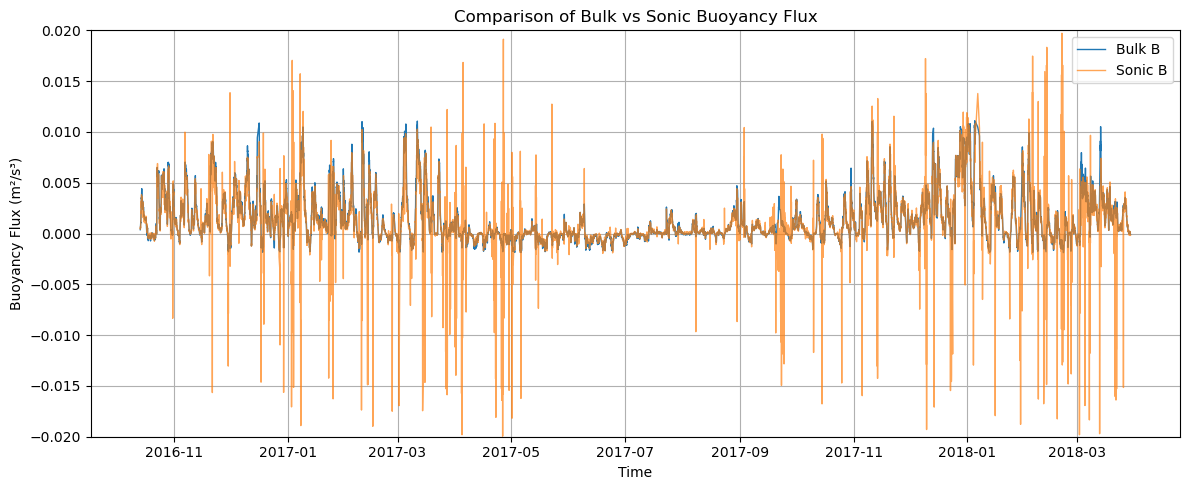

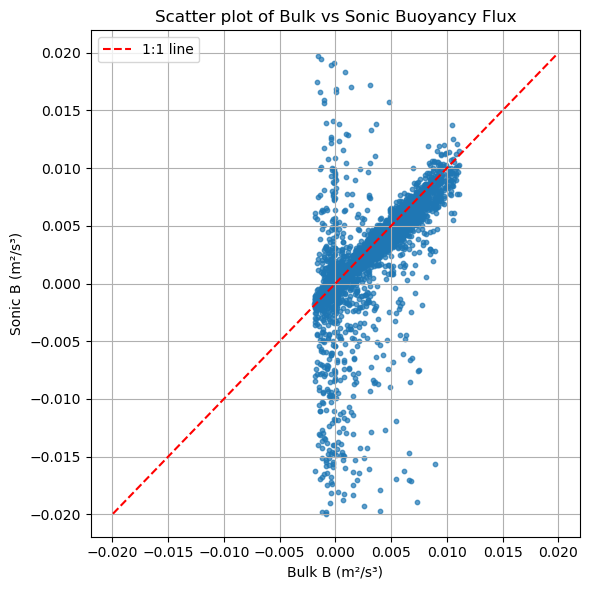

Correlation: 0.695


In [47]:
# Time series
plt.figure(figsize=(12,5))
plt.plot(bflux['time'], bflux['bulk_B'], label='Bulk B', lw=1)
plt.plot(bflux['time'], bflux['sonic_B'], label='Sonic B', lw=1, alpha=0.7)
plt.xlabel("Time")
plt.ylim(-0.02, 0.02)
plt.ylabel("Buoyancy Flux (m²/s³)")
plt.title("Comparison of Bulk vs Sonic Buoyancy Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(bflux['bulk_B'], bflux['sonic_B'], s=10, alpha=0.7)
max_val = max(
    abs(bflux['bulk_B']).max(),
    abs(bflux['sonic_B']).max()
)
plt.plot([-max_val, max_val], [-max_val, max_val], 'r--', label='1:1 line')
plt.xlabel("Bulk B (m²/s³)")
plt.ylabel("Sonic B (m²/s³)")
plt.title("Scatter plot of Bulk vs Sonic Buoyancy Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlation
corr_clean = np.corrcoef(bflux['bulk_B'], bflux['sonic_B'])[0,1]
print(f"Correlation: {corr_clean:.3f}")

# Task 5

Explore the impact of the diurnal warm layer effect on the parameterized sensible and latent heat fluxes. In AirSeaFluxCode, these effects can be switched on/off for certain bulk schemes (page 12 of Biri et al. (2023). For example, you can compare three scenarios for sensible heat flux between
 - With cool skin and a warm layer
 - No cool skin and no warm layer
We expect the diurnal cycle of SST to be large under low wind conditions. Do you see that in the data as well?

In [78]:
outvars = ["sensible", "latent"]
sst = df['Tsea'].to_numpy()
short_rad = df['Solar'].to_numpy()
long_rad = df['IR'].to_numpy()

def run_ASFC(c_skin, wlayer):
    res = asfc.AirSeaFluxCode(
        spd,
        t,
        sst,
        "bulk",
        meth='LP82',
        lat=lat,
        hin=10,
        hout=10,
        hum=["rh", rh],
        P=p,
        Rs=short_rad,
        Rl=long_rad,
        cskin=c_skin,
        convert=True,
        wl=wlayer,
        out_var=outvars,
    )
    return res

params = np.array([
    ['Both on', 'Both off', 'Warm only', 'Cool only' ],          # trial
    [1, 0, 0, 1],  # cool_skin
    [1, 0, 1, 0]    # warm_layer
])
param_df = pd.DataFrame(params.T, columns=['trial', 'cool_skin', 'warm_layer'])

In [122]:
results = []

for _, row in param_df.iterrows():
    trial_name = row["trial"]

    for outvar in ["sensible","latent"]:

        res = run_ASFC(int(row["cool_skin"]), int(row["warm_layer"]))

        # remove bad flags
        res_clean = res[res["flag"] == "n"].copy()

        res_clean["time"] = df["time"]
        res_clean["trial"] = trial_name
        res_clean["flux_type"] = outvar

        res_clean = res_clean[[outvar,"time","trial","flux_type"]]
        res_clean = res_clean.rename(columns={outvar:"flux"})

        results.append(res_clean)



In [139]:
flux_df = pd.concat(results)
flux_df = flux_df.pivot_table(
    index=["time","flux_type"],
    columns="trial",
    values="flux"
).reset_index()

#Flip sign
cols_to_flip = ["Both off", "Both on", "Cool only", "Warm only"]
flux_df[cols_to_flip] = -flux_df[cols_to_flip]

In [140]:
flux_df["warm_layer_effect"] = flux_df["Warm only"] - flux_df["Both off"]
flux_df["cool_skin_effect"] = flux_df["Cool only"] - flux_df["Both off"]
flux_df["combined_effect"] = flux_df["Both on"] - flux_df["Both off"]

#convert to eastern time for diurnal analysis
flux_df['time'] = pd.to_datetime(flux_df['time'], utc=True)
flux_df['time_local'] = flux_df['time'].dt.tz_convert('America/New_York')
flux_df['hour'] = flux_df['time_local'].dt.hour

diurnal = flux_df.groupby(["hour","flux_type"]).mean().reset_index()

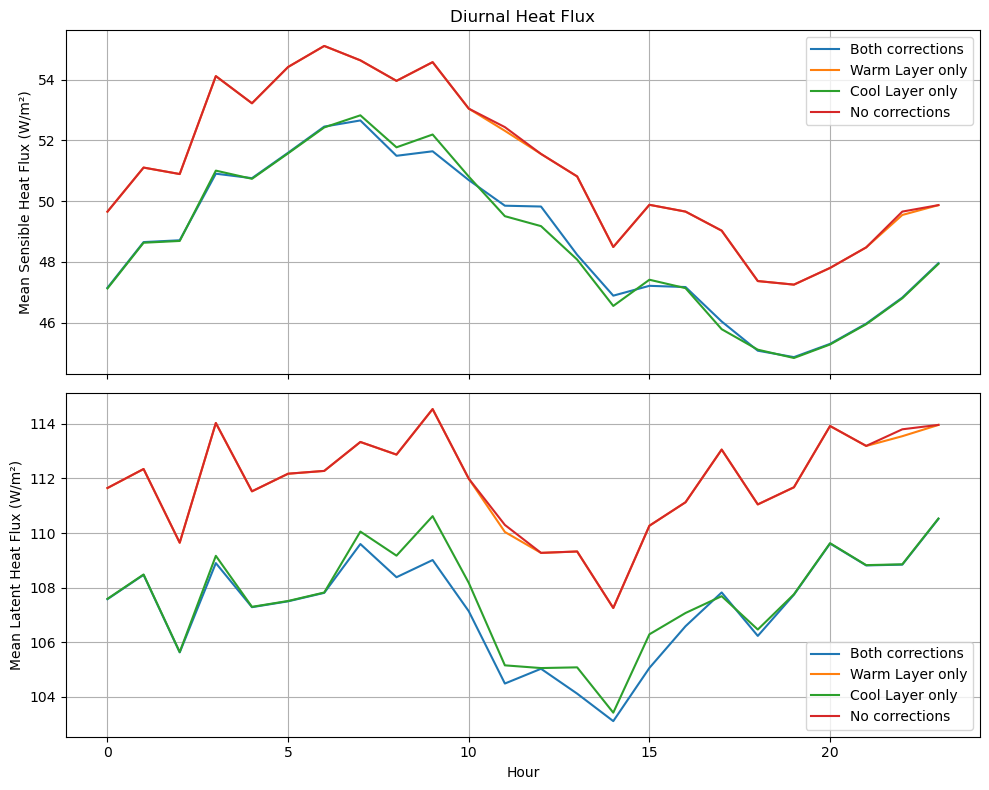

In [171]:
shf = diurnal[diurnal["flux_type"]=="sensible"]
lhf = diurnal[diurnal["flux_type"]=="latent"]

fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

#sensible
axes[0].plot(shf["hour"], shf["Both on"], label="Both corrections")
axes[0].plot(shf["hour"], shf["Warm only"], label="Warm Layer only")
axes[0].plot(shf["hour"], shf["Cool only"], label="Cool Layer only")
axes[0].plot(shf["hour"], shf["Both off"], label="No corrections")
axes[0].set_ylabel("Mean Sensible Heat Flux (W/m²)")
axes[0].set_title("Diurnal Heat Flux")
axes[0].legend()
axes[0].grid(True)

#latent
axes[1].plot(lhf["hour"], lhf["Both on"], label="Both corrections")
axes[1].plot(lhf["hour"], lhf["Warm only"], label="Warm Layer only")
axes[1].plot(lhf["hour"], lhf["Cool only"], label="Cool Layer only")
axes[1].plot(lhf["hour"], lhf["Both off"], label="No corrections")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Mean Latent Heat Flux (W/m²)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


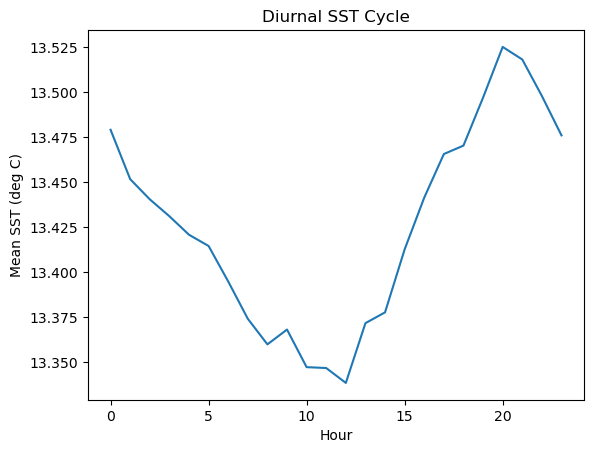

In [205]:
sst_diurnal = df.groupby("hour")["SST"].mean()

plt.plot(sst_diurnal)
plt.xlabel("Hour")
plt.ylabel("Mean SST (deg C)")
plt.title("Diurnal SST Cycle")
plt.show()

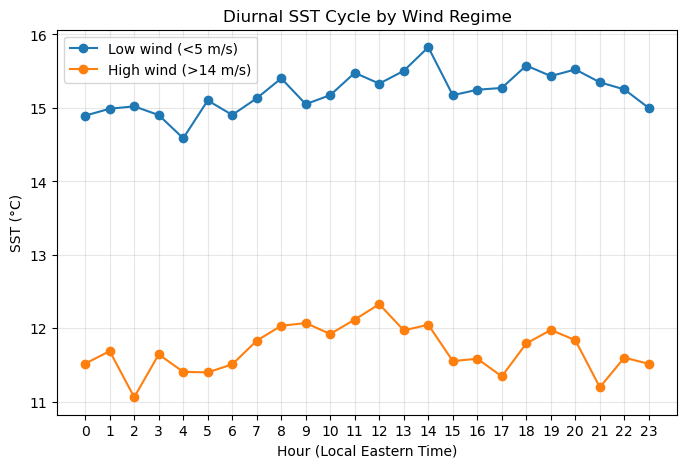

In [220]:
df['hour_local'] = df['time'].dt.tz_convert('America/New_York').dt.hour
sst_hourly = df.groupby('hour_local').apply( lambda g: g.loc[g['U10r'] < 5, 'SST'].mean() )
sst_hourly_high = df.groupby('hour_local').apply( lambda g: g.loc[g['U10r'] > 14, 'SST'].mean())

plt.figure(figsize=(8,5))

#low-wind
plt.plot(sst_hourly.index, sst_hourly.values, label='Low wind (<5 m/s)', marker='o')
#high-wind
plt.plot(sst_hourly_high.index, sst_hourly_high.values, label='High wind (>15 m/s)', marker='o')

plt.xlabel('Hour (Local Eastern Time)')
plt.ylabel('SST (°C)')
plt.title('Diurnal SST Cycle by Wind Regime')
plt.xticks(range(0,24))  # optional: show all hours
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()